# PEMS08 Traffic Flow Prediction — Colab GPU T4 Edition
**Target: MAE ≤ 13**

### Steps:
1. Upload `PEMS08.npz` to Colab (or mount Google Drive)
2. Runtime → Change runtime type → **GPU (T4)**
3. Run all cells

In [1]:
# ── Option A: Upload file directly ──────────────────────────────────────────
from google.colab import files
uploaded = files.upload()   # pick PEMS08.npz from your computer
DATA_PATH = list(uploaded.keys())[0]

# ── Option B: Mount Google Drive (comment out Option A above if using this) ─
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_PATH = '/content/drive/MyDrive/PEMS08.npz'   # adjust path as needed

Saving PEMS08.npz to PEMS08.npz


In [2]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))
    print('Memory:', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB')

Using device: cuda
GPU: Tesla T4
Memory: 15.6 GB


In [3]:
import numpy as np
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

In [4]:
data = np.load(DATA_PATH)
arr  = data['data']   # (time, sensors, features)
flow = arr[:, :, 0]   # traffic flow only
print('Dataset shape:', flow.shape)

Dataset shape: (17856, 170)


In [5]:
split_index = int(0.8 * len(flow))
train_flow  = flow[:split_index]

mean = train_flow.mean()
std  = train_flow.std()

flow = (flow - mean) / std
print(f'Normalised — mean={mean:.2f}, std={std:.2f}')

Normalised — mean=230.56, std=146.18


In [6]:
SEQ_LEN  = 48   # longer context window
PRED_LEN = 1

X, Y = [], []
for i in range(len(flow) - SEQ_LEN - PRED_LEN):
    X.append(flow[i : i + SEQ_LEN])
    Y.append(flow[i + SEQ_LEN : i + SEQ_LEN + PRED_LEN])

X = np.array(X, dtype=np.float32)
Y = np.array(Y, dtype=np.float32)

split     = int(0.8  * len(X))
val_split = int(0.9  * split)

X_train, Y_train = X[:val_split],  Y[:val_split]
X_val,   Y_val   = X[val_split:split], Y[val_split:split]
X_test,  Y_test  = X[split:],      Y[split:]

print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')

Train: (12820, 48, 170) | Val: (1425, 48, 170) | Test: (3562, 48, 170)


In [7]:
class TrafficDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.from_numpy(X)
        self.Y = torch.from_numpy(Y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

# Larger batch size — T4 has 16 GB VRAM, use it!
BATCH = 256

train_loader = DataLoader(TrafficDataset(X_train, Y_train), batch_size=BATCH, shuffle=True,  pin_memory=True, num_workers=2)
val_loader   = DataLoader(TrafficDataset(X_val,   Y_val),   batch_size=BATCH, shuffle=False, pin_memory=True, num_workers=2)
test_loader  = DataLoader(TrafficDataset(X_test,  Y_test),  batch_size=BATCH, shuffle=False, pin_memory=True, num_workers=2)

In [8]:
class LSTMTransformer(nn.Module):
    def __init__(self, sensors=170, hidden=192):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=sensors,
            hidden_size=hidden,
            num_layers=3,
            batch_first=True,
            dropout=0.1
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden,
            nhead=8,
            dim_feedforward=512,
            dropout=0.05,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=3)
        self.fc = nn.Linear(hidden, sensors)

    def forward(self, x):
        x, _ = self.lstm(x)
        x     = self.transformer(x)
        x     = self.fc(x[:, -1, :])
        return x.unsqueeze(1)

model = LSTMTransformer().to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters: {total_params:,}')

Model parameters: 1,944,170


In [9]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.00015)
criterion = nn.HuberLoss(delta=1.0)   # robust to outliers

EPOCHS    = 120
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

patience         = 15
best_val_loss    = float('inf')
patience_counter = 0
train_losses, val_losses = [], []

for epoch in range(EPOCHS):

    # ── Training ────────────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0

    for x, y in train_loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)

        optimizer.zero_grad()
        pred = model(x)
        loss = criterion(pred, y)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.5)
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # ── Validation ──────────────────────────────────────────────────────────
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            val_loss += criterion(model(x), y).item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    scheduler.step()

    print(f'Epoch {epoch+1:3d} | Train {train_loss:.4f} | Val {val_loss:.4f} | LR {scheduler.get_last_lr()[0]:.2e}')

    # ── Early stopping ──────────────────────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print('Early stopping triggered')
        break

model.load_state_dict(torch.load('best_model.pth'))
print('Best model loaded!')

Epoch   1 | Train 0.1688 | Val 0.0815 | LR 1.50e-04
Epoch   2 | Train 0.0464 | Val 0.0611 | LR 1.50e-04
Epoch   3 | Train 0.0356 | Val 0.0557 | LR 1.50e-04
Epoch   4 | Train 0.0309 | Val 0.0523 | LR 1.50e-04
Epoch   5 | Train 0.0278 | Val 0.0500 | LR 1.49e-04
Epoch   6 | Train 0.0256 | Val 0.0488 | LR 1.49e-04
Epoch   7 | Train 0.0238 | Val 0.0471 | LR 1.49e-04
Epoch   8 | Train 0.0225 | Val 0.0459 | LR 1.48e-04
Epoch   9 | Train 0.0214 | Val 0.0453 | LR 1.48e-04
Epoch  10 | Train 0.0206 | Val 0.0438 | LR 1.47e-04
Epoch  11 | Train 0.0198 | Val 0.0434 | LR 1.47e-04
Epoch  12 | Train 0.0192 | Val 0.0425 | LR 1.46e-04
Epoch  13 | Train 0.0186 | Val 0.0423 | LR 1.46e-04
Epoch  14 | Train 0.0181 | Val 0.0414 | LR 1.45e-04
Epoch  15 | Train 0.0176 | Val 0.0411 | LR 1.44e-04
Epoch  16 | Train 0.0172 | Val 0.0404 | LR 1.44e-04
Epoch  17 | Train 0.0169 | Val 0.0401 | LR 1.43e-04
Epoch  18 | Train 0.0166 | Val 0.0391 | LR 1.42e-04
Epoch  19 | Train 0.0162 | Val 0.0387 | LR 1.41e-04
Epoch  20 | 

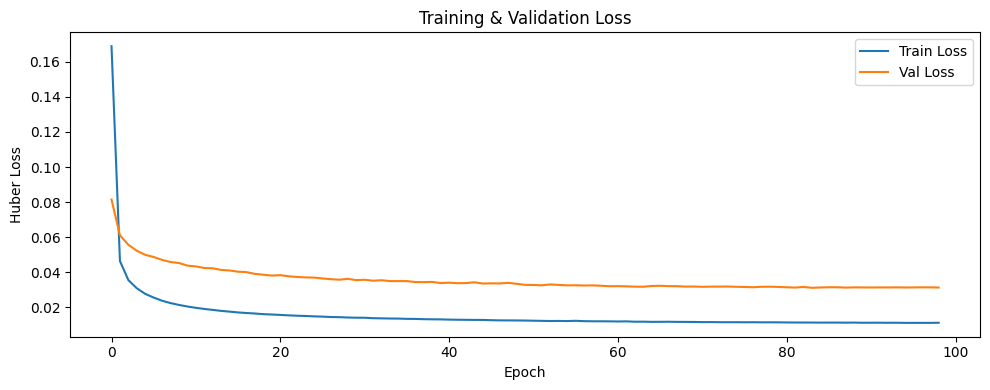

In [10]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Huber Loss')
plt.title('Training & Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

MAE:  17.8619
RMSE: 26.8626
MAPE: 12.0357%  (flow > 1 only)


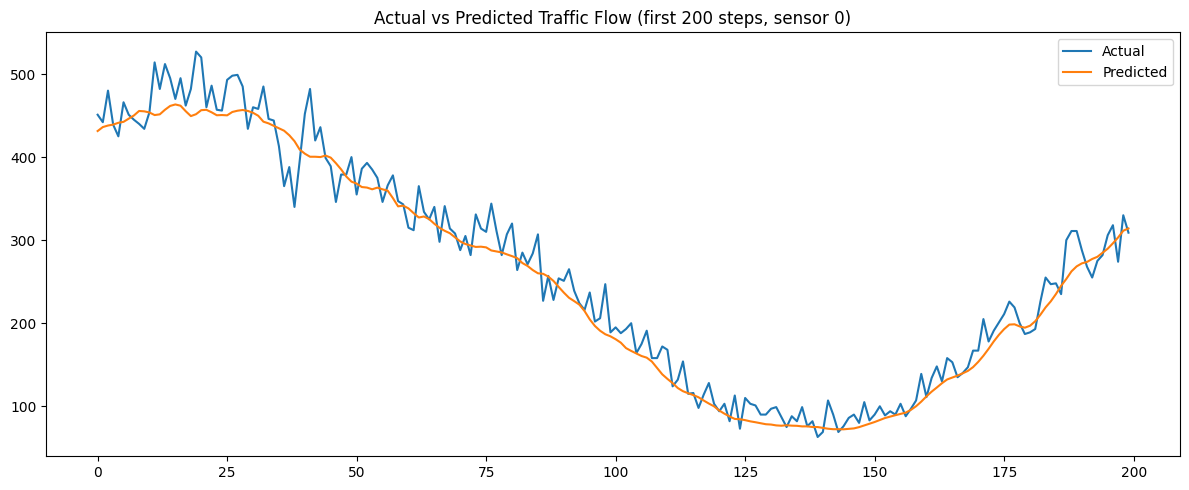

In [11]:
model.eval()
preds, actual = [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device, non_blocking=True)
        preds.append(model(x).cpu().numpy())
        actual.append(y.numpy())

preds  = np.concatenate(preds)
actual = np.concatenate(actual)

# Denormalise
preds  = preds  * std + mean
actual = actual * std + mean

# Metrics
mae  = mean_absolute_error(actual.flatten(), preds.flatten())
rmse = np.sqrt(mean_squared_error(actual.flatten(), preds.flatten()))

# MAPE — skip near-zero flow to avoid division explosion
mask = actual.flatten() > 1.0
mape = np.mean(np.abs((actual.flatten()[mask] - preds.flatten()[mask]) /
                       actual.flatten()[mask])) * 100

print(f'MAE:  {mae:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAPE: {mape:.4f}%  (flow > 1 only)')

# Plot
plt.figure(figsize=(12, 5))
plt.plot(actual[:200, 0, 0], label='Actual')
plt.plot(preds[:200,  0, 0], label='Predicted')
plt.legend()
plt.title('Actual vs Predicted Traffic Flow (first 200 steps, sensor 0)')
plt.tight_layout()
plt.show()